# Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

# Initial Exploration

In [3]:
df.shape

(2443651, 9)

In [4]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [6]:
df.dtypes

uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [8]:
df.isnull().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

# Exploring numerical and categorical variables

In [10]:
# Retrieving the unique data types present in the dataframe columns
list(set(df.dtypes.tolist()))

[dtype('int64'), dtype('O'), dtype('float64'), dtype('bool')]

In [11]:
# Extracting column names with numerical data types from the dataframe
df.select_dtypes("number").columns

Index(['uid', 'stars', 'reviews', 'price', 'boughtInLastMonth'], dtype='object')

In [12]:
# Counting and sorting the unique values for each numerical column in descending order
df.select_dtypes("number").nunique().sort_values(ascending=False)

uid                  2443651
price                  82916
reviews                19446
stars                     42
boughtInLastMonth         25
dtype: int64

In [16]:
# Separating between discrete and continuous variables, as discrete ones could potentially be treated as categorical.
# Remember to adjust the threshold (in this case, < 50) based on your dataset's specific characteristics and domain knowledge.
potential_categorical_from_numerical = df.select_dtypes("number").loc[:, df.select_dtypes("number").nunique() < 50]
potential_categorical_from_numerical

,stars,boughtInLastMonth
0,4.7,0
1,4.7,0
2,4.7,0
3,4.7,0
4,4.6,0
...,...,...
2443646,0.0,0
2443647,0.0,0
2443648,0.0,0
2443649,4.3,0


## Erased UID column since its not relevant for the analysis

In [14]:
df = df.drop(columns=['uid'])

In [15]:
df.columns

Index(['asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

# Separating variables

In [17]:
numerical_cols = ['stars', 'reviews', 'price', 'boughtInLastMonth'] #Didn't add title or asin

In [18]:
categorical_cols = ['category', 'isBestSeller']

# Data Cleaning

In [19]:
# Checking for missing data
df.isnull().sum().sort_values(ascending=False)

asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [20]:
# Identifying columns in the dataframe where over 80% of the values are missing
df.columns[df.isnull().mean() > 0.8] #None this time

Index([], dtype='object')

In [21]:
# Filtering out columns in the dataframe where more than 80% of the values are missing
df = df[df.columns[df.isnull().mean() < 0.8]] #None this time

# Univariate Analysis

## Categorical Variables

In [22]:
df ['category'].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [23]:
df['category'].value_counts(normalize = True)

category
Sports & Outdoors                         0.342219
Beauty                                    0.007903
Handmade Clothing, Shoes & Accessories    0.007869
Bath & Body                               0.007813
Birthday Gifts                            0.007766
                                            ...   
Alexa Built-In Devices                    0.000044
Motorbike Chassis                         0.000044
Plugs                                     0.000044
Smart Home Security & Lighting            0.000043
Smart Speakers                            0.000022
Name: proportion, Length: 296, dtype: float64

### Which are the top 5 most listed product categories?

In [30]:
category_proportions = df['category'].value_counts(normalize=True) * 100
category_proportions

category
Sports & Outdoors                         34.221949
Beauty                                     0.790293
Handmade Clothing, Shoes & Accessories     0.786896
Bath & Body                                0.781290
Birthday Gifts                             0.776625
                                            ...    
Alexa Built-In Devices                     0.004379
Motorbike Chassis                          0.004379
Plugs                                      0.004379
Smart Home Security & Lighting             0.004256
Smart Speakers                             0.002210
Name: proportion, Length: 296, dtype: float64

In [24]:
top_5_categories = df['category'].value_counts().head(5)

top_5_categories

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

The frequency table shows that Sports & Outdoors is the most listed product category by a large margin. The next most listed categories are Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body, and Birthday Gifts, but their listing counts are much lower compared with Sports & Outdoors.

## Visualization

/var/folders/6y/g3t2k_6s01x98hz602dv0npw0000gn/T/ipykernel_70966/3583198736.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


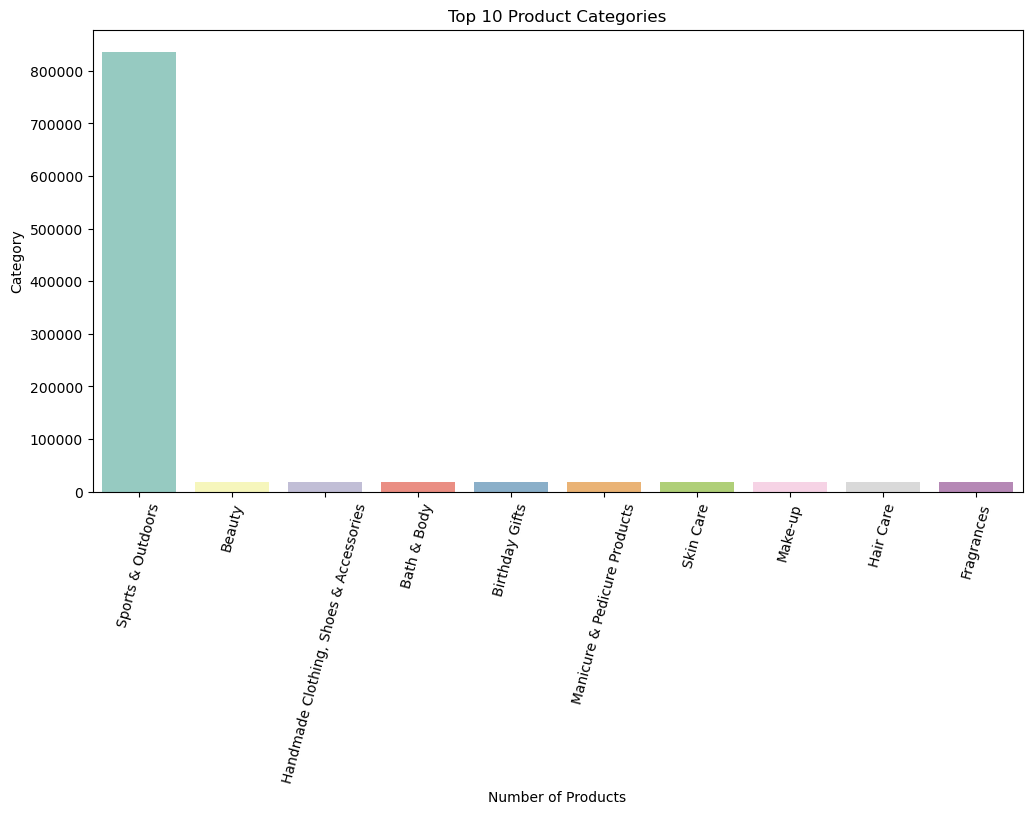

In [27]:
top_10_categories = df['category'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_10_categories.index,
    y=top_10_categories.values,
    palette = 'Set3'
)

plt.title('Top 10 Product Categories')
plt.xlabel('Number of Products')
plt.ylabel('Category')

plt.xticks(rotation =75)

plt.show()

The bar chart confirms that the distribution of listings is highly imbalanced. Sports & Outdoors dominates the top categories, while remaining categories have much smaller and relatively similar listing frequencies. This suggests that Sports & Outdoors is highly competitive and product-diverse segment on Amazon.

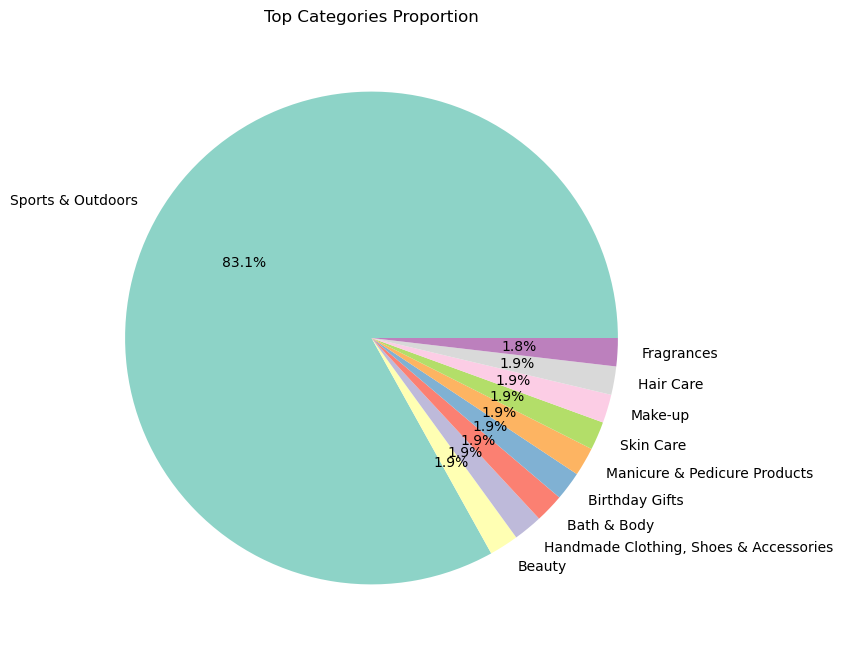

In [45]:
top_10_categories.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8),
    colors=sns.color_palette("Set3")
)

plt.title('Top Categories Proportion')
plt.ylabel('')

plt.show()

The pie chart shows that Sports & Outdoors represents approximately 83% of the top 10 category listings. No other category individually reaches 2%, confirming that this category strongly dominates the product listing distribution.

From business perspective, this indicates that Amazon has very high contribution

Overall, the most popular product category is Sports & Outdoors. It clearly dominates the dataset in terms of listing frequency. The other top categories, such as Beauty, Bath & Body, Skin Care, Make-up, and Hair Care, are present but represent much smaller shares of the listings.

Therefore, no category distribution is balanced. Sports & Outdoors dominates the marketplace listings among the top categories.

## How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

#### Measures of Centrality - PRICE

In [31]:
price_mean = df['price'].mean()
price_median = df['price'].median()
price_mode = df['price'].mode()[0]

print("Mean price:", price_mean)
print("Median price:", price_median)
print("Mode price:", price_mode)

Mean price: 89.24380943923661
Median price: 19.09
Mode price: 9.99


The average product price is higher than the median price, which suggests a positively skewed distribution. This indicates that while most products are relatively inexpensive, there are some highly priced products increasing the average price.

The mode represents the most common price point among the listed products, being 9.99.

#### Measures of Dispersion

In [32]:
price_variance = df['price'].var()
price_std = df['price'].std()

price_min = df['price'].min()
price_max = df['price'].max()

price_range = price_max - price_min

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

print("Variance:", price_variance)
print("Standard Deviation:", price_std)
print("Minimum Price:", price_min)
print("Maximum Price:", price_max)
print("Range:", price_range)
print("Interquartile Range:", IQR)

Variance: 119445.4853225653
Standard Deviation: 345.6088617535223
Minimum Price: 0.0
Maximum Price: 100000.0
Range: 100000.0
Interquartile Range: 36.0


The measures of dispersion reveal a very high variability in product prices across the Amazon UK marketplace.

The standard deviation is extremely large compared to the interquartile range, which indicates that the dataset contains significant outliers and extreme price values.

The minimum product price is 0, while the maximum reaches 100,000, creating a massive price range of 100,000. This suggests the presence of either luxury products, data anomalies, or unusually priced listings.

The interquartile range (IQR) is relatively small compared to the total range, which means that most products are concentrated within a much narrower price interval, while only a small number of products extend into extremely high price ranges.

#### Shape of Distribution

In [33]:
price_skewness = df['price'].skew()
price_kurtosis = df['price'].kurtosis()

print("Skewness:", price_skewness)
print("Kurtosis:", price_kurtosis)

Skewness: 27.49297756628037
Kurtosis: 4241.616412866521


The price distribution is extremely positively skewed, as indicated by the very high skewness value (27.49). This means that the majority of products are concentrated in low price ranges, while a small number of products have extremely high prices.

Additionally, the kurtosis value is extremely high (4241.62), which indicates the presence of many extreme outliers. The distribution has very heavy tails and deviates significantly from a normal distribution.

These results confirm that Amazon UK product pricing is highly uneven, with most products being relatively inexpensive and a limited number of premium or anomalous products extending the distribution.

#### Histogram

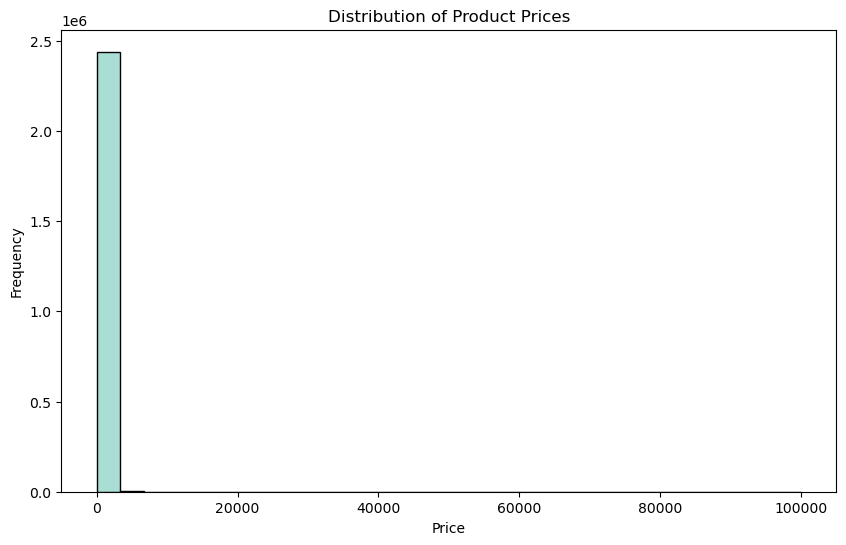

In [42]:
plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=30, color=sns.color_palette("Set3")[0])

plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

The original histogram is difficult to interpret because a small number of extremely expensive products stretch the scale of the distribution.

Most products are concentrated in the lower price ranges, but the existence of outliers with prices reaching up to 100,000 compresses the visualization and hides the detailed structure of the majority of the data.

This behavior is consistent with the previously observed strong positive skewness and high kurtosis.

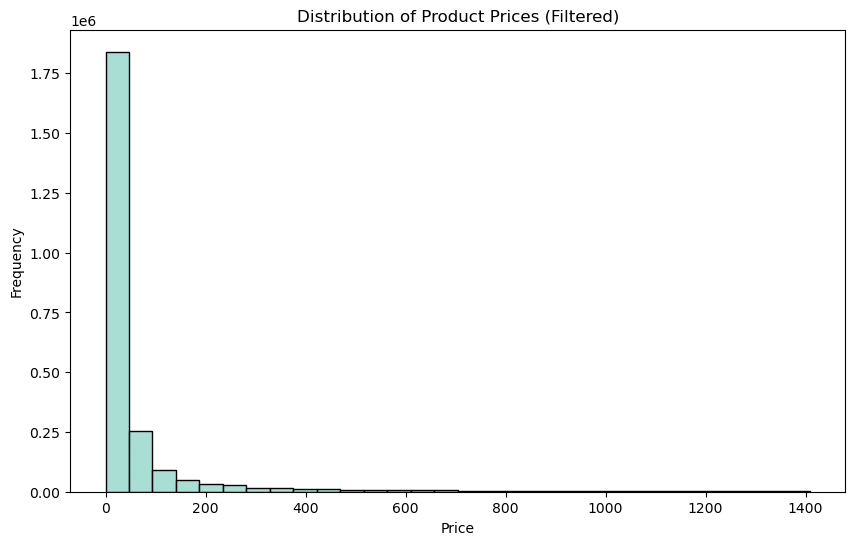

In [40]:
price_filtered = df[df['price'] < df['price'].quantile(0.99)]

plt.figure(figsize=(10,6))

sns.histplot(price_filtered['price'], bins=30, color=sns.color_palette("Set3")[0])

plt.title('Distribution of Product Prices (Filtered)')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

After filtering extreme outliers above the 99th percentile, the distribution becomes significantly easier to interpret.

The filtered histogram shows that most products are concentrated in relatively low and medium price ranges, with frequencies decreasing progressively as prices increase.

Even after removing the most extreme outliers, the distribution still remains positively skewed, indicating that low-priced products dominate the marketplace.

#### Boxplot

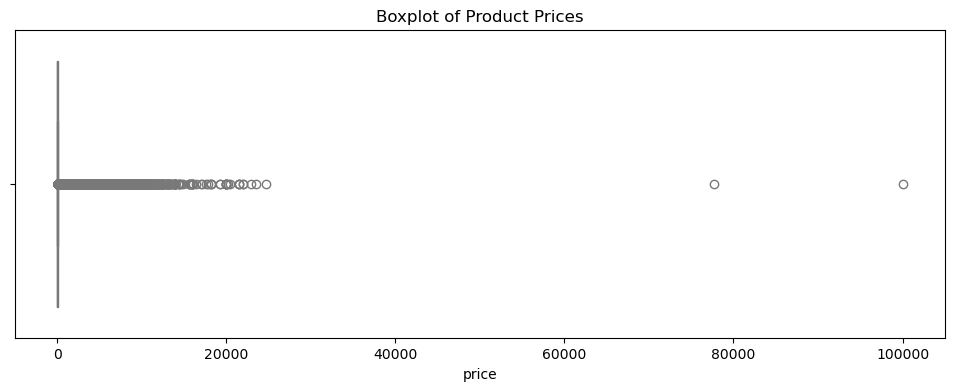

In [41]:
plt.figure(figsize=(12,4))

sns.boxplot(x=df['price'], color=sns.color_palette("Set3")[2])

plt.title('Boxplot of Product Prices')

plt.show()

The boxplot clearly reveals the presence of numerous extreme outliers in product prices.

Most products are concentrated within a relatively narrow lower-price range, while a smaller number of products extend far beyond the upper whiskers.

The visualization confirms that the Amazon UK marketplace contains a few exceptionally expensive products that heavily influence the overall price distribution.

## Final Business Insight

Overall, Amazon UK product prices are highly dispersed and strongly right-skewed.

Most products are concentrated in affordable price ranges, while a relatively small number of premium-priced products create substantial variability and extreme outliers in the dataset.

The marketplace therefore appears to combine mass-market low-cost products with a smaller segment of high-value or luxury listings.